In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [5]:
data = pd.read_csv("./data/Taitanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 📚 척도의 종류 (Measurement Scales) 정리

| 척도 구분    | 특징 | 예시 | 타이타닉 데이터 예시 |
|:------------|:----|:----|:----------------|
| **명목척도 (Nominal Scale)** | - 분류만 가능<br>- 서열 없음<br>- 수학적 연산 불가 | 성별, 지역, 혈액형, 선호도 등 | - 성별 (male, female)<br>- 승선 항구 (C, Q, S) |
| **순서척도 (Ordinal Scale)** | - 분류 가능 + 서열 있음<br>- 크기 차이는 불명확<br>- 덧셈, 뺄셈 불가 | 선호도(1순위, 2순위...), 학년, 고객 만족도 등 | - 선실 등급 (1st, 2nd, 3rd) |
| **구간척도 (Interval Scale)** | - 분류 가능 + 서열 있음 + 간격 의미 있음<br>- 하지만 절대 0이 없음<br>- 비율 계산 불가 | 온도(섭씨), 지수(지능지수 IQ 등) | (타이타닉에는 구간척도 예시는 특별히 없음)<br>- 가상의 예로 "탑승객 만족 점수 (0~100 점)" |
| **비율척도 (Ratio Scale)** | - 분류 가능 + 서열 있음 + 간격 의미 + 절대 0 존재<br>- 사칙연산 모두 가능 (비율 연산 가능) | 키, 몸무게, 나이, 수입, 점수 | - 나이 (Age)<br>- 운임 요금 (Fare)<br>- 형제/배우자 수 (SibSp), 부모/자식 수 (Parch) |

---


| 변수명  | 척도 종류 | 이유 |
|:-------|:---------|:-----|
| `Sex` (성별) | 명목척도 | 남자, 여자 구분만 가능. 남자가 여자보다 크다거나 작다는 개념 없음. |
| `Embarked` (승선항구) | 명목척도 | 탑승한 항구(C=쉘버그, Q=퀸스타운, S=사우샘프턴)는 단순 구분일 뿐, 크고 작음이 없음. |
| `Pclass` (선실 등급) | 순서척도 | 1등실 > 2등실 > 3등실 로 서열은 존재하지만, 1등실과 2등실 간 '차이'가 2등실과 3등실 간 '차이'와 같은지는 알 수 없음. |
| `Age` (나이) | 비율척도 | 0세가 절대적 기준, 나이의 비율 계산 가능 (20살은 10살의 2배). |
| `Fare` (운임) | 비율척도 | 0원이 절대적 기준, 100파운드는 50파운드의 2배. |
| `SibSp`, `Parch` (형제/배우자, 부모/자식 수) | 비율척도 | 0이 기준이고, 숫자 간 비율 의미 있음. |

# 이상값 탐지
* 이상값 : 데이터 집합에서 다른 값들과 뚜렷하게 다른 값
* 통계적으로 평균을 왜곡시킴, 모델의 결과를 왜곡시킬 수 있음
* 전체 데이터 분포에서 **정상 범위**에 속하지 않는 데이터

## 이상값 탐지 방법 3가지
* Z-score가 -3 ~ +3 범위를 넘어가는 경우 : 극단적인 이상값을 탐지
* 평균을 기준으로 평균에서 ±(3 * 표준편차)를 넘는 경우 : 표준편차가 큰 경우에는 잘 잡지 못함
* IQR(사분위수) 기준으로 계산한 상위 하위 이상값을 넘는 경우 : 정규,비정규분포에서 모두 강함

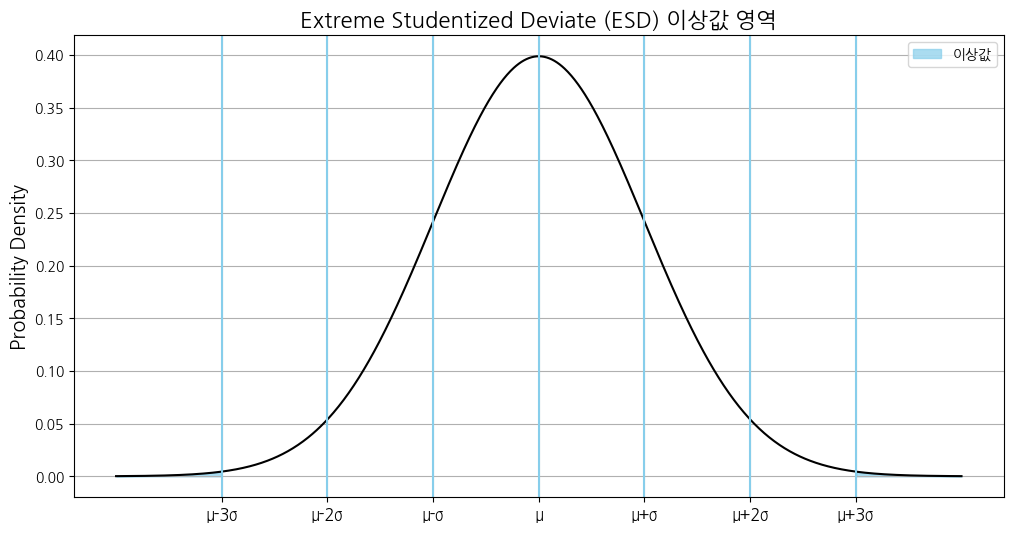

# 상자수염그림(boxplot)을 이용해서 컬럼의 이상치 여부 판단하기

# 이상치 처리 방법 6가지
| 방법 | 설명 | 주의사항 |
|:----|:----|:----|
| 1. 삭제 (제거) | 이상치인 행(row) 삭제 | 데이터 수가 많을 때만 추천 |
| 2. 대체 (수정) | 평균, 중앙값 등으로 이상치 값을 대체 | 대체 값이 데이터의 특성을 망가뜨릴 수 있음 |
| 3. 변환 | 로그(log), 루트(sqrt) 변환해서 이상치 영향을 줄이기 | 주로 오른쪽으로 긴 분포(Skewed Data) |
| 4. 구간 압축 (Winsorization) | 상/하위 극단값을 일정 값으로 '컷' | 통계 왜곡 최소화할 때 사용 |
| 5. 모델링 시 Robust 방법 사용 | 이상치에 강한 모델 사용 (예: RobustScaler, RANSAC) | 이상치를 제거하지 않고 대응 |
| 6. 별도 분석 | 이상치만 따로 분석해서 인사이트 얻기 | 이상치가 중요한 의미를 가질 때 |
* 가장먼저 할 것은 이상치 분석